In [41]:

# Functions + imports
#################################################################################################################
# Core libraries for cleaning, grouping, merging, and quick plots.
# (Note: sklearn LinearRegression imported but not used here; ok to keep for later baseline comparisons.)

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import math
try:
    import statsmodels.api as sm
    HAVE_SM = True
except Exception as e:
    HAVE_SM = False
    print("statsmodels not available -> will use ratio-quantile fallback.")
    print("Error:", e)   

FREQ = pd.Timedelta(minutes=15)

def parse_dnr(d): 
    """
    'D0411' -> 411
    'D1354' -> 1354
    """
    s = str(d).strip()
    if not s or not s.startswith("D"):
        return None
    digits = s[1:].lstrip("0")  # remove 'D' and leading zeros
    if digits == "":
        return None
    return int(digits)


def make_expected_grid(df, freq=FREQ):
    """Build full expected 15-min grid per (substation, transformer) over its observed span."""
    out = []
    for (sid, tr), g in df.groupby(["substation_id", "transformer"]):
        t0 = g["ts"].min()
        t1 = g["ts"].max()
        grid = pd.date_range(t0, t1, freq=freq)
        out.append(pd.DataFrame({"substation_id": sid, "transformer": tr, "ts": grid}))
    return pd.concat(out, ignore_index=True)


def compute_ct_diagnostics(
    merged: pd.DataFrame,
    min_points: int = 50,
    min_current: float = 5.0,
) -> pd.DataFrame:
    """
    Per-(substation, transformer) diagnostics to detect CT scaling vs unmetered load.

    Expects columns in merged:
      substation_id, transformer, ts,
      I_total_sm, I_total_jn, n_mps, per_completed

    Assumes:
      - Janitza should be an upper bound for true current
        → in a physically consistent situation, I_total_sm <= I_total_jn
        (ignoring noise / mapping mistakes).
    """
    rows = []

    required = {"substation_id", "transformer", "I_total_sm", "I_total_jn"}
    missing = required - set(merged.columns)
    if missing:
        raise KeyError(f"compute_ct_diagnostics: merged is missing required columns: {sorted(missing)}")

    # Normalize transformer just in case
    m = merged.copy()
    m["transformer"] = m["transformer"].astype(str).str.strip().str.lower()

    for (sid, tr), g in m.groupby(["substation_id", "transformer"], dropna=False):
        g = g.copy()

        # Filter out very low currents (ratios get crazy near zero)
        mask = (g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)
        g = g[mask]
        if len(g) < min_points:
            continue  # not enough data

        x = g["I_total_sm"].to_numpy()
        y = g["I_total_jn"].to_numpy()

        # --- 1) Physical sanity: how often is SMD > Janitza? ---
        sm_gt_jn = (g["I_total_sm"] > g["I_total_jn"])
        frac_sm_gt_jn = float(sm_gt_jn.mean())

        # --- 2) Unconstrained linear fit: y ≈ alpha * x + beta ---
        alpha_ls, beta = np.polyfit(x, y, 1)

        y_pred = alpha_ls * x + beta
        ss_res = float(np.sum((y - y_pred) ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

        # Correlation (shape similarity)
        corr = g["I_total_jn"].corr(g["I_total_sm"])

        # --- 3) Ratio-based view: y/x distribution ---
        ratio = (g["I_total_jn"] / g["I_total_sm"]).replace([np.inf, -np.inf], np.nan).dropna()
        ratio_median = float(ratio.median()) if not ratio.empty else np.nan
        ratio_std = float(ratio.std()) if not ratio.empty else np.nan
        ratio_min = float(ratio.min()) if not ratio.empty else np.nan
        ratio_p05 = float(ratio.quantile(0.05)) if len(ratio) > 0 else np.nan

        # --- 4) "CT scaling" factor under your physical constraint ---
        if float(np.sum(x**2)) > 0:
            alpha0 = float(np.sum(x * y) / np.sum(x**2))
        else:
            alpha0 = np.nan

        alpha_max_phys = ratio_p05  # use ratio_min if you want strict
        if (not np.isnan(alpha0)) and (not np.isnan(alpha_max_phys)):
            alpha_ct = min(alpha0, alpha_max_phys)
        else:
            alpha_ct = np.nan

        # --- 5) Smart-meter completeness & expected alpha from coverage ---
        if "per_completed" in g.columns:
            per_completed = float(pd.to_numeric(g["per_completed"], errors="coerce").max())
            if per_completed > 1.5:  # handle 0–100 scale
                per_completed = per_completed / 100.0
        else:
            per_completed = np.nan

        n_mps = float(pd.to_numeric(g["n_mps"], errors="coerce").max()) if "n_mps" in g.columns else np.nan

        if per_completed and (not np.isnan(per_completed)) and per_completed > 0:
            expected_alpha = 1.0 / per_completed
        else:
            expected_alpha = np.nan

        if (not np.isnan(expected_alpha)) and (not np.isnan(alpha_ct)):
            alpha_over_expected = alpha_ct / expected_alpha
        else:
            alpha_over_expected = np.nan

        rows.append({
            "substation_id": sid,
            "transformer": tr,   # 👈 NEW OUTPUT KEY
            # Unconstrained regression fit (with intercept)
            "alpha_ls": float(alpha_ls),
            "beta": float(beta),
            "r2": float(r2) if not np.isnan(r2) else np.nan,
            "corr": float(corr) if corr is not None else np.nan,
            # Physically constrained CT-like factor
            "alpha_ct": alpha_ct,
            "alpha0_through_origin": alpha0,
            "ratio_min": ratio_min,
            "ratio_p05": ratio_p05,
            "ratio_median": ratio_median,
            "ratio_std": ratio_std,
            # Coverage + expectation
            "per_completed": per_completed,
            "n_mps": n_mps,
            "expected_alpha_from_coverage": expected_alpha,
            "alpha_over_expected": alpha_over_expected,
            # Conservation violation diagnostics
            "frac_sm_gt_jn": frac_sm_gt_jn,
            "n_points": int(len(g)),
        })

    return pd.DataFrame(rows)


def plot_substation_timeseries(merged, sid, alpha=None, max_points=2000):
    g = merged[merged["substation_id"] == sid].sort_values("ts")
    if len(g) > max_points:
        g = g.iloc[:max_points]

    plt.figure(figsize=(12, 4))
    plt.plot(g["ts"], g["I_total_jn"], label="Janitza I_total")
    plt.plot(g["ts"], g["I_total_sm"], label="Smartmeters I_total")

    if alpha is not None:
        plt.plot(g["ts"], alpha * g["I_total_sm"], "--", label=f"SMD * {alpha:.2f}")

    plt.title(f"Substation {sid} – total current")
    plt.xlabel("Time")
    plt.ylabel("Current [A]")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_substation_scatter(merged, sid, transformer=None, alpha=None):
    g = merged[merged["substation_id"] == sid].copy()
    if transformer is not None:
        g = g[g["transformer"].astype(str).str.strip().str.lower() == str(transformer).strip().lower()]

    if g.empty:
        raise ValueError(f"No rows found for substation_id={sid}, transformer={transformer}")

    plt.figure(figsize=(5, 5))
    plt.scatter(g["I_total_sm"], g["I_total_jn"], s=5, alpha=0.3, label="JD vs SMD")

    max_i = max(g["I_total_sm"].max(), g["I_total_jn"].max())
    plt.plot([0, max_i], [0, max_i], "k--", label="JD = SMD")

    if alpha is not None:
        xs = np.linspace(0, max_i, 100)
        plt.plot(xs, alpha * xs, label=f"JD = {alpha:.2f}·SMD")

    plt.xlabel("SMD I_total [A]")
    plt.ylabel("JD I_total [A]")
    tx = f" | {transformer}" if transformer else ""
    plt.title(f"Substation {sid}{tx} – scatter")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_robust_comparison(stats_df, top_n=300):
    """
    Plots MAE (Amps), RMSE (Amps), and WAPE (%) stacked vertically.
    stats_df is indexed by (substation_id, transformer).
    """
    data = stats_df.head(top_n).copy()

    x = np.arange(len(data))
    width = 0.35
    subs = [f"{sid}_{tr}" for (sid, tr) in data.index]  # 👈 nicer labels

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

    ax1.bar(x - width/2, data["MAE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax1.bar(x + width/2, data["MAE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    ax1.set_ylabel('MAE [Amps]')
    ax1.set_title(f'Mean Absolute Error (MAE) - Top {top_n} (Substation, Trafo)')
    ax1.legend()
    ax1.grid(True, axis='y', alpha=0.3)

    ax2.bar(x - width/2, data["RMSE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax2.bar(x + width/2, data["RMSE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    ax2.set_ylabel('RMSE [Amps]')
    ax2.set_title('Root Mean Square Error (RMSE)')
    ax2.grid(True, axis='y', alpha=0.3)

    ax3.bar(x - width/2, data["WAPE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax3.bar(x + width/2, data["WAPE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    ax3.set_ylabel('WAPE [%]')
    ax3.set_title('Weighted Percentage Error (WAPE)')
    ax3.set_xticks(x)
    ax3.set_xticklabels(subs, rotation=90)
    ax3.grid(True, axis='y', alpha=0.3)

    for i, n in enumerate(data["n_mps"]):
        y_pos = max(data["WAPE_Before"].iloc[i], data["WAPE_After"].iloc[i])
        offset = 0.05 * data["WAPE_Before"].max()
        ax3.text(i, y_pos + offset, f"n={int(n)}", ha='center', fontsize=8, rotation=90)

    plt.tight_layout()
    plt.show()


def plot_substation_timeseries_grid(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    substation_transformers=None,   # NEW: list of (substation_id, transformer) pairs
    min_per_completed: float = 0.7,
    max_plots: int = 12,
    cols: int = 4,
    max_points: int = 2000,
):
    """
    Grid of time series plots per (substation, transformer).

    For each (substation, transformer):
      - plots Janitza I_total_jn
      - plots Smartmeter I_total_sm
      - if alpha_ct is available in `summary`, also plots alpha_ct * I_total_sm
    """

    # Defensive normalize transformer strings
    merged = merged.copy()
    summary = summary.copy()
    if "transformer" not in merged.columns or "transformer" not in summary.columns:
        raise KeyError("Both merged and summary must contain a 'transformer' column.")

    merged["transformer"] = merged["transformer"].astype(str).str.strip().str.lower()
    summary["transformer"] = summary["transformer"].astype(str).str.strip().str.lower()

    # --- choose which (substation, transformer) pairs to plot ---
    if substation_transformers is not None:
        pairs = [(sid, str(tr).strip().lower()) for sid, tr in list(substation_transformers)[:max_plots]]
        cand = summary.merge(
            pd.DataFrame(pairs, columns=["substation_id", "transformer"]),
            on=["substation_id", "transformer"],
            how="inner",
        )
    else:
        cand = summary[summary["per_completed"] >= min_per_completed].copy()

        # Sort by alpha_over_expected if available, else by (substation_id, transformer)
        if "alpha_over_expected" in cand.columns:
            cand = cand.sort_values("alpha_over_expected", ascending=False)
        else:
            cand = cand.sort_values(["substation_id", "transformer"])

        cand = cand.head(max_plots)

        pairs = list(zip(cand["substation_id"], cand["transformer"]))

    if not pairs:
        print("No (substation, transformer) pairs to plot (check filters or substation_transformers).")
        return

    # Lookup diagnostics by (substation_id, transformer)
    summary_idx = summary.set_index(["substation_id", "transformer"])

    # --- create grid of subplots ---
    n_plots = len(pairs)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(6 * cols, 3 * rows),
        sharex=True,
        sharey=False,
    )
    axes = np.array(axes).reshape(-1)

    for ax, (sid, tr) in zip(axes, pairs):
        g = merged[(merged["substation_id"] == sid) & (merged["transformer"] == tr)].sort_values("ts")

        if g.empty:
            ax.set_visible(False)
            continue

        if len(g) > max_points:
            g = g.iloc[:max_points]

        # alpha_ct for this (sid, tr)
        alpha = None
        if "alpha_ct" in summary.columns and (sid, tr) in summary_idx.index:
            alpha_val = summary_idx.loc[(sid, tr), "alpha_ct"]
            try:
                alpha = float(alpha_val)
            except Exception:
                alpha = None

        # Plot original currents
        ax.plot(g["ts"], g["I_total_jn"], label="Janitza I_total")
        ax.plot(g["ts"], g["I_total_sm"], label="Smartmeters I_total")

        # Optional CT-scaled smartmeter line
        if alpha is not None and np.isfinite(alpha):
            ax.plot(g["ts"], alpha * g["I_total_sm"], "--", label=f"SMD × {alpha:.2f}")

        # Title
        title = f"Sub {sid} {tr}"
        if "corr" in summary.columns and (sid, tr) in summary_idx.index:
            try:
                title += f"\nρ={float(summary_idx.loc[(sid, tr), 'corr']):.2f}"
            except Exception:
                pass
        if "per_completed" in summary.columns and (sid, tr) in summary_idx.index:
            try:
                title += f", per={float(summary_idx.loc[(sid, tr), 'per_completed']):.2f}"
            except Exception:
                pass

        ax.set_title(title, fontsize=9)
        ax.set_ylabel("I_total [A]")
        ax.legend(fontsize=8)

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # x-label only on bottom row
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        if row_idx == rows - 1:
            ax.set_xlabel("Time")

    fig.suptitle("Transformer total current – JD vs SM (with CT scaling)", y=0.98)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


def calculate_robust_metrics(df_in, sm_col="I_total_sm", jn_col="I_total_jn", min_current_mape=5.0):
    """
    Calculates row-wise error metrics and aggregates them per (substation_id, transformer).
    Returns a DataFrame indexed by (substation_id, transformer).
    """
    df = df_in.copy()

    # Defensive normalize transformer
    if "transformer" in df.columns:
        df["transformer"] = df["transformer"].astype(str).str.strip().str.lower()
    else:
        raise KeyError("calculate_robust_metrics: df_in must contain a 'transformer' column now.")

    # 1. Basic Difference
    df["diff"] = df[sm_col] - df[jn_col]
    df["abs_diff"] = df["diff"].abs()
    df["sq_diff"] = df["diff"] ** 2

    # 2. Standard MAPE (filtered)
    high_load_mask = df[sm_col] > min_current_mape
    df["mape_filtered"] = np.nan
    df.loc[high_load_mask, "mape_filtered"] = (
        100 * df.loc[high_load_mask, "abs_diff"] / df.loc[high_load_mask, sm_col]
    )

    # 3. SMAPE
    denom = (df[sm_col].abs() + df[jn_col].abs()) / 2
    df["smape"] = 100 * df["abs_diff"] / denom.replace(0, np.nan)

    # --- AGGREGATION (NOW PER substation + transformer) ---
    stats = df.groupby(["substation_id", "transformer"]).agg(
        # Context
        n_points      = (sm_col, "count"),
        n_mps         = ("n_mps", "max"),
        per_completed = ("per_completed", "max"),

        # Absolute Errors (Amps)
        MAE           = ("abs_diff", "mean"),
        RMSE          = ("sq_diff", lambda x: np.sqrt(x.mean())),

        # Percentage Errors
        MAPE_filtered_mean = ("mape_filtered", "mean"),
        SMAPE_mean         = ("smape", "mean"),

        # Sums for WAPE
        sum_abs_diff = ("abs_diff", "sum"),
        sum_sm_total = (sm_col, "sum"),
    )

    stats["WAPE"] = 100 * stats["sum_abs_diff"] / stats["sum_sm_total"].replace(0, np.nan)
    return stats


def plot_scatter_grid(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    min_per_completed: float = 0.9,
    max_plots: int = 12,
    cols: int = 4,
    min_points: int = 50,
    min_current: float = 5.0,
    normalize: bool = True,
):
    """
    Grid of scatter plots for each (substation_id, transformer):
        x = I_total_sm (smartmeters)
        y = I_total_jn (Janitza)

    When normalize=True, both axes in each subplot are scaled so that
    max(I_total_sm, I_total_jn) for that pair becomes 1.0.
    The slope α is preserved.
    """

    # Basic required cols
    for c in ["substation_id", "transformer", "I_total_sm", "I_total_jn"]:
        if c not in merged.columns:
            raise KeyError(f"merged missing column: {c}")
    for c in ["substation_id", "transformer", "per_completed", "n_points", "alpha_ct", "alpha_over_expected", "r2"]:
        if c not in summary.columns:
            raise KeyError(f"summary missing column: {c}")

    # Normalize transformer strings (defensive)
    merged = merged.copy()
    merged["transformer"] = merged["transformer"].astype(str).str.strip().str.lower()
    summary = summary.copy()
    summary["transformer"] = summary["transformer"].astype(str).str.strip().str.lower()

    # Filter to reasonably complete (substation, transformer) groups
    cand = summary[
        (summary["per_completed"] >= min_per_completed) &
        (summary["n_points"] >= min_points)
    ].copy()

    if cand.empty:
        print("No (substation, transformer) groups meet the per_completed and n_points filters.")
        return

    # Sort so the “worst” ones come first
    cand = cand.sort_values("alpha_over_expected", ascending=False).head(max_plots)

    n_plots = len(cand)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(4 * cols, 4 * rows),
        sharex=not normalize,
        sharey=not normalize,
    )
    axes = np.array(axes).reshape(-1)

    # If NOT normalizing, compute global max across selected pairs
    global_max = 0.0
    if not normalize:
        for _, r in cand.iterrows():
            sid = r["substation_id"]
            tr = r["transformer"]
            g = merged[(merged["substation_id"] == sid) & (merged["transformer"] == tr)].copy()
            g = g[(g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)]
            if g.empty:
                continue
            local_max = max(g["I_total_sm"].max(), g["I_total_jn"].max())
            global_max = max(global_max, local_max)

        if global_max == 0:
            print("All filtered groups have zero currents after filtering.")
            return

    # Actual plotting
    for ax, (_, row) in zip(axes, cand.iterrows()):
        sid = row["substation_id"]
        tr = row["transformer"]
        alpha = row["alpha_ct"]
        per_completed = row["per_completed"]
        alpha_over_exp = row["alpha_over_expected"]
        r2 = row["r2"]

        g = merged[(merged["substation_id"] == sid) & (merged["transformer"] == tr)].copy()
        g = g[(g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)]
        if g.empty:
            ax.set_visible(False)
            continue

        if normalize:
            local_max = max(g["I_total_sm"].max(), g["I_total_jn"].max())
            if local_max == 0:
                ax.set_visible(False)
                continue
            x = g["I_total_sm"] / local_max
            y = g["I_total_jn"] / local_max
            xs = np.linspace(0, 1, 100)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        else:
            x = g["I_total_sm"]
            y = g["I_total_jn"]
            xs = np.linspace(0, global_max, 100)
            ax.set_xlim(0, global_max)
            ax.set_ylim(0, global_max)

        ax.scatter(x, y, s=5, alpha=0.3)
        ax.plot(xs, xs, "k--", linewidth=1)                 # JD = SMD
        ax.plot(xs, alpha * xs, linewidth=1)                # JD = alpha * SMD

        ax.set_title(
            f"Sub {sid} {tr}\n"
            f"α={alpha:.2f}, r²={r2:.2f}\n"
            f"per={per_completed:.2f}, α/α_exp={alpha_over_exp:.2f}"
        )

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # Axis labels only on outer edges
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        col_idx = i % cols
        if row_idx == rows - 1:
            ax.set_xlabel("I_total_sm (normalized)" if normalize else "I_total_sm [A]")
        if col_idx == 0:
            ax.set_ylabel("I_total_jn (normalized)" if normalize else "I_total_jn [A]")

    plt.suptitle(
        f"JD vs SMD scatter – (substation, trafo) with per_completed ≥ {min_per_completed}",
        y=0.98,
    )
    plt.tight_layout()
    plt.show()


def fit_k_quantile_per_group(df_reg: pd.DataFrame, tau: float = 0.20, min_points: int = 200):
    """
    Fits per-group quantile regression:
      I_total_jn ≈ b + k * I_total_sm_adj
    Returns k_hat and b_hat per (substation_id, transformer) plus QC metrics.

    QC metrics connect to thesis justification:
      - corr_xy, r2_ols: does it look like a strong linear relationship?
      - frac_x_gt_y: how often does SM_adj exceed Janitza? (should be ~0 if mapping/physics OK)
      - frac_neg_resid: how often the fitted model predicts above the data (y < yhat) for a low quantile
    """
    rows = []
    for (sid, tr), g in df_reg.groupby(["substation_id", "transformer"]):
        if len(g) < min_points:
            continue

        x = g["I_total_sm_adj"].to_numpy(dtype=float)
        y = g["I_total_jn"].to_numpy(dtype=float)

        # require positive x for regression stability
        m = np.isfinite(x) & np.isfinite(y) & (x > 0)
        x = x[m]; y = y[m]
        if len(x) < min_points:
            continue

        # --- shape sanity ---
        corr_xy = float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else np.nan

        # --- physics sanity (raw): how often does SM_adj exceed Janitza? ---
        # This should be near 0 if mapping + scaling are consistent.
        frac_x_gt_y = float(np.mean(x > y))

        per = float(g["per_completed"].iloc[0])

         # Quantile regression with intercept (main diagnostic fit)
        if HAVE_SM:
            X = sm.add_constant(x)  # [1, x]
            try:
                mod = sm.QuantReg(y, X)
                res = mod.fit(q=tau, max_iter=2000)
                b = float(res.params[0])
                k = float(res.params[1])
            except Exception:
                # if solver struggles, fall back to ratio-quantile
                r = y / x
                k = float(np.nanquantile(r, tau))
                b = 0.0
        else:
            # fallback: quantile of ratios (no intercept)
            r = y / x
            k = float(np.nanquantile(r, tau))
            b = 0.0

        # Physics/QC check:
        # For a low quantile fit, residuals should not be massively negative too often.
        yhat = b + k * x
        resid = y - yhat
        frac_neg = float(np.mean(resid < -1e-6))  # tolerance

        # OLS R^2 only for reporting "linearity quality" (NOT used for estimation)
        try:
            k_ols, b_ols = np.polyfit(x, y, 1)
            y_pred = k_ols * x + b_ols
            ss_res = np.sum((y - y_pred)**2)
            ss_tot = np.sum((y - y.mean())**2)
            r2_ols = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        except Exception:
            r2_ols = np.nan

        rows.append({
            "substation_id": sid,
            "transformer": tr,
            "tau": tau,
            "k_hat": k,     # slope estimate (CT scaling candidate)
            "b_hat": b,     # intercept estimate (diagnostic; usually not applied in correction)
            "corr_xy": corr_xy,
            "frac_x_gt_y": frac_x_gt_y,
            "per_completed": per,
            "n_points": int(len(x)),
            "frac_neg_resid": frac_neg,
            "r2_ols": r2_ols,
            "k_hat_log10": np.log10(k) if (k is not None and np.isfinite(k) and k > 0) else np.nan,
        })

    return pd.DataFrame(rows).sort_values(["k_hat"], ascending=False)


def detect_transformer_swaps(df_reg, min_points=2000, corr_gain=0.05):
    """
    Transformer swap detection (thesis: "failure mode / data quality diagnostic")
    --------------------------------------------------------------------------
    If substation has both sp1 and sp2, check whether SM_adj(sp1) correlates more
    with Janitza(sp2) than Janitza(sp1) AND likewise SM_adj(sp2) correlates more
    with Janitza(sp1) than Janitza(sp2).

    If both cross-correlations are better by corr_gain -> flag swap_suspect.
    These groups should be excluded or remapped before interpreting k.
    """
    out = []
    need = ["substation_id", "transformer", "ts", "I_total_sm_adj", "I_total_jn"]
    for c in need:
        if c not in df_reg.columns:
            raise KeyError(f"detect_transformer_swaps: df_reg missing {c}")

    for sid, gs in df_reg.groupby("substation_id"):
        trafos = set(gs["transformer"].astype(str).str.lower().unique())
        if not {"sp1", "sp2"}.issubset(trafos):
            continue

        g1 = gs[gs["transformer"].str.lower() == "sp1"][["ts","I_total_sm_adj","I_total_jn"]].rename(
            columns={"I_total_sm_adj":"x1","I_total_jn":"y1"}
        )
        g2 = gs[gs["transformer"].str.lower() == "sp2"][["ts","I_total_sm_adj","I_total_jn"]].rename(
            columns={"I_total_sm_adj":"x2","I_total_jn":"y2"}
        )

        h = g1.merge(g2, on="ts", how="inner")
        if len(h) < min_points:
            continue

        c11 = h["x1"].corr(h["y1"])  # sp1 with sp1
        c22 = h["x2"].corr(h["y2"])  # sp2 with sp2
        c12 = h["x1"].corr(h["y2"])  # sp1 with sp2 (cross)
        c21 = h["x2"].corr(h["y1"])  # sp2 with sp1 (cross)

        best_same = np.nanmax([c11, c22])
        best_cross = np.nanmax([c12, c21])

        swap = (c12 > c11 + corr_gain) and (c21 > c22 + corr_gain)

        out.append({
            "substation_id": sid,
            "n_points_pair": int(len(h)),
            "corr_sp1": float(c11) if pd.notna(c11) else np.nan,
            "corr_sp2": float(c22) if pd.notna(c22) else np.nan,
            "corr_cross_1to2": float(c12) if pd.notna(c12) else np.nan,
            "corr_cross_2to1": float(c21) if pd.notna(c21) else np.nan,
            "best_same": float(best_same) if pd.notna(best_same) else np.nan,
            "best_cross": float(best_cross) if pd.notna(best_cross) else np.nan,
            "gain_cross_minus_same": float(best_cross - best_same) if pd.notna(best_same) and pd.notna(best_cross) else np.nan,
            "swap_suspect": bool(swap),
        })

    return pd.DataFrame(out).sort_values("gain_cross_minus_same", ascending=False)


def fit_k_no_intercept(df_reg, tau=0.20, min_points=200):
    """
    Fits quantile regression WITHOUT intercept:
      I_total_jn ≈ k0 * I_total_sm_adj
    Often preferred for CT scaling correction because it enforces 0->0 behavior.
    """
    rows = []
    for (sid,tr), g in df_reg.groupby(["substation_id","transformer"]):
        if len(g) < min_points:
            continue
        x = g["I_total_sm_adj"].to_numpy(float)
        y = g["I_total_jn"].to_numpy(float)
        m = np.isfinite(x) & np.isfinite(y) & (x > 0)
        x = x[m]; y = y[m]
        if len(x) < min_points:
            continue

        if HAVE_SM:
            # X is just x, no constant column
            try:
                res = sm.QuantReg(y, x).fit(q=tau, max_iter=2000)
                k0 = float(res.params[0])
            except Exception:
                k0 = float(np.nanquantile(y/x, tau))
        else:
            k0 = float(np.nanquantile(y/x, tau))

        rows.append({"substation_id": sid, "transformer": tr, "tau": tau, "k_hat0": k0, "n_points": len(x)})
    return pd.DataFrame(rows)

#################################################################################################################

In [42]:
## Load + preprocess + align time bins (this is the "make the join trustworthy" section)
#################################################################################################################
sm_current_path = "../data/smartmeter_15min_all_by_transformer_20250801_20251101_['LPQ_Current_L1_AVG', 'LPQ_Current_L2_AVG', 'LPQ_Current_L3_AVG'].parquet"
jn_current_path ="../data/all_substations_current_202508-202511.parquet" #"../data/janitza_3phase_I_by_transformer_20250801_0000_20251101_0000.parquet" 
#"../data/janitza_3phase_I_by_transformer_20250801_0000_20251101_0000.parquet"
# Read raw parquet outputs
df_sm_current = pd.read_parquet(sm_current_path)
df_jn_current = pd.read_parquet(jn_current_path)

# Normalize transformer key to avoid merge failures ("SP1" vs "sp1", whitespace, etc.)
for d in (df_sm_current, df_jn_current):
    if "transformer" in d.columns:
        d["transformer"] = d["transformer"].astype(str).str.strip().str.lower()

# Add numeric substation_id from Janitza naming convention
df_jn_current["substation_id"] = df_jn_current["dnr_str"].map(parse_dnr)

# Optional: exclude known broken substations (manual blacklist)
exclude_dnr = ["D1133"]  # e.g. ["D0303", "D1454","D1554","D1049"]
df_jn_current = df_jn_current[~df_jn_current["dnr_str"].isin(exclude_dnr)].copy()
# =========================================================
# NEW FILTER: Exclude Low-Meter-Count Groups (n_mps <= 2)
# =========================================================
# We calculate max meters seen per group to determine if it's "low meter count"
if "n_mps" in df_sm_current.columns:
    # 1. Identify valid groups
    valid_groups = (
        df_sm_current.groupby(["substation_id", "transformer"])["n_mps"]
        .max()
        .reset_index()
    )
    valid_groups = valid_groups[valid_groups["n_mps"] > 2] # Strict > 2 (so 3 or more)
    
    print(f"Filtering: Keeping {len(valid_groups)} groups with > 2 meters.")
    
    # 2. Filter Smart Meter DataFrame
    df_sm_current = df_sm_current.merge(
        valid_groups[["substation_id", "transformer"]], 
        on=["substation_id", "transformer"], 
        how="inner"
    )
    
    # 3. Filter Janitza DataFrame (to avoid processing irrelevant stations)
    df_jn_current = df_jn_current.merge(
        valid_groups[["substation_id", "transformer"]], 
        on=["substation_id", "transformer"], 
        how="inner"
    )
else:
    print("WARNING: 'n_mps' column missing in Smart Meter data. skipping low-meter filter.")
# =========================================================
# Sort for readability + predictable operations
df_sm_current = df_sm_current.sort_values(["substation_id", "ts"])
df_jn_current = df_jn_current.sort_values(["substation_id", "ts"])

# Timestamp normalization:
# - Smartmeter data typically already timezone-naive
# - Janitza often comes with timezone awareness (UTC); convert and strip tz to compare properly in pandas merges
df_sm_current["ts"] = pd.to_datetime(df_sm_current["ts"])
df_jn_current["ts"] = pd.to_datetime(df_jn_current["ts"], utc=True).dt.tz_localize(None)

# Keep only substations that exist in Janitza (we only regress where both sources exist)
jn_substations = df_jn_current["substation_id"].unique()
df_sm_current = df_sm_current[df_sm_current["substation_id"].isin(jn_substations)].copy()

# Ensure both are datetime (defensive)
df_sm_current["ts"] = pd.to_datetime(df_sm_current["ts"])
df_jn_current["ts"] = pd.to_datetime(df_jn_current["ts"])


# Key alignment fix:
# Janitza timestamps may be slightly offset from exact 15-min boundaries.
# We snap to 15-min bins with tolerance, avoiding "ceil gaps" that create missing bins.
tol = pd.Timedelta(seconds=10)  # small tolerance window

ts_raw = df_jn_current["ts"]
t_floor = ts_raw.dt.floor("15min")
offset = ts_raw - t_floor


# If timestamp is only a few seconds after boundary -> treat as boundary.
# Else snap up (ceil) so bins align with the smartmeter aggregator convention.
df_jn_current["ts"] = t_floor.where(offset <= tol, ts_raw.dt.ceil("15min"))

# Trim both datasets to same end time to avoid trailing bins in one source only
max_ts_sm = df_sm_current["ts"].max()
df_sm_current = df_sm_current[df_sm_current["ts"] < max_ts_sm].copy()
df_jn_current = df_jn_current[df_jn_current["ts"] < max_ts_sm].copy()

# Janitza collisions:
# If Janitza has multiple rows per (substation, transformer, ts) (device-level or exporter duplication),
# we aggregate to one record per bin. Mean is a pragmatic choice here; document in thesis.
num_cols = ["I_a", "I_b", "I_c", "I_total"]
df_jn_current = (
    df_jn_current
    .groupby(["substation_id", "ts", "transformer"], as_index=False)[num_cols]
    .mean()
)

# Define the "comparison universe":
# We only compare bins where Janitza exists (JD-present bins). This avoids blaming smartmeters for missing Janitza buckets.
grid = make_expected_grid(df_jn_current, freq=FREQ)
jn_bins = df_jn_current[["substation_id", "ts", "transformer"]].drop_duplicates()

grid = grid.merge(
    jn_bins.assign(jn_present=1),
    on=["substation_id", "ts", "transformer"],
    how="left"
)
grid["jn_present"] = grid["jn_present"].fillna(0).astype(int)

good_bins = grid[grid["jn_present"] == 1][["substation_id", "ts", "transformer"]]

# Filter both sources to exactly these bins (merge safety + fair comparison)
df_jn_good = df_jn_current.merge(good_bins, on=["substation_id", "ts", "transformer"], how="inner")
df_sm_good = df_sm_current.merge(good_bins, on=["substation_id", "ts", "transformer"], how="inner")

# Sanity: sizes and duplicate key checks (crucial when joins feel scary)
print("Original:", df_jn_current.shape, df_sm_current.shape)
print("Common-bin:", df_jn_good.shape, df_sm_good.shape)

print("Duplicate keys in JN good:", df_jn_good.duplicated(["substation_id", "ts", "transformer"]).sum())
print("Duplicate keys in SM good:", df_sm_good.duplicated(["substation_id", "ts", "transformer"]).sum())

#################################################################################################################


Filtering: Keeping 58 groups with > 2 meters.
Original: (449151, 7) (459264, 9)
Common-bin: (449151, 7) (449151, 9)
Duplicate keys in JN good: 0
Duplicate keys in SM good: 0


In [43]:
# Merge smartmeter + Janitza into one frame (this is the regression input "panel dataset")
#################################################################################################################
# After this merge:
#   Each row = one 15-min bin for one (substation_id, transformer)
#   Contains both currents, coverage metadata, etc.
df_merged = df_sm_good.merge(
    df_jn_good,
    on=["substation_id", "ts","transformer"],
    how="inner",             # intersection only
    suffixes=("_sm", "_jn"),
    validate="one_to_one"    # safety check: raises if keys aren't 1:1
)
# Quick differences (not the final model, but good for debugging & intuition)
for col in ["I_a", "I_b", "I_c", "I_total"]:
    df_merged[f"{col}_diff"] = df_merged[f"{col}_sm"] - df_merged[f"{col}_jn"]

df_merged[["I_a_diff", "I_b_diff", "I_c_diff", "I_total_diff"]].describe()

print("Merged shape:",df_merged.shape)
#################################################################################################################
df_merged.head()

Merged shape: (449151, 17)


,substation_id,transformer,ts,I_a_sm,I_b_sm,I_c_sm,I_total_sm,n_mps,per_completed,I_a_jn,I_b_jn,I_c_jn,I_total_jn,I_a_diff,I_b_diff,I_c_diff,I_total_diff
0,6,sp2,2025-08-01 00:00:00,224.770,215.335,211.150,651.255,14,0.146789,334.560343,316.556108,286.038940,937.155392,-109.790343,-101.221108,-74.888940,-285.900392
1,6,sp2,2025-08-01 00:15:00,220.430,215.320,209.960,645.710,14,0.146789,323.902763,302.985018,278.322723,905.210505,-103.472763,-87.665018,-68.362723,-259.500505
2,6,sp2,2025-08-01 00:30:00,222.475,213.615,208.580,644.670,14,0.146789,311.500031,286.178909,269.614471,867.293411,-89.025031,-72.563909,-61.034471,-222.623411
3,6,sp2,2025-08-01 00:45:00,218.680,217.510,208.410,644.600,14,0.146789,310.368235,287.293504,276.940643,874.602382,-91.688235,-69.783504,-68.530643,-230.002382
4,6,sp2,2025-08-01 01:00:00,217.710,213.430,204.795,635.935,14,0.146789,299.206396,276.543036,263.939636,839.689068,-81.496396,-63.113036,-59.144636,-203.754068


Rows for substation 1496 : 8830


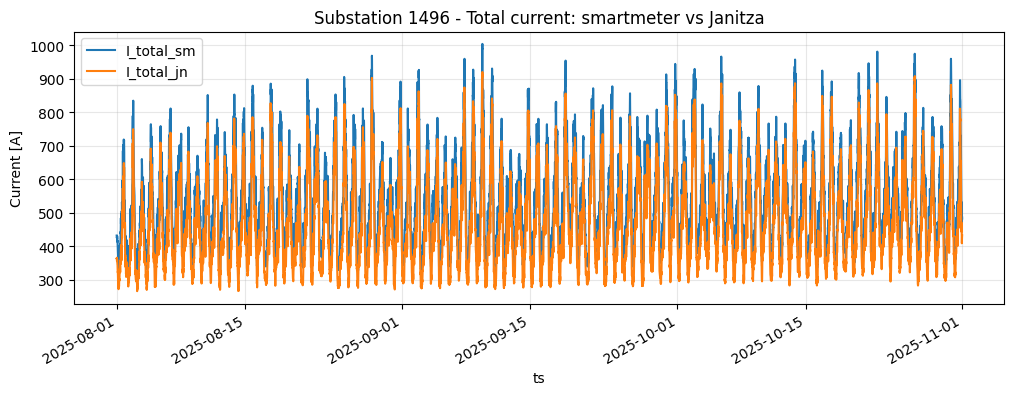

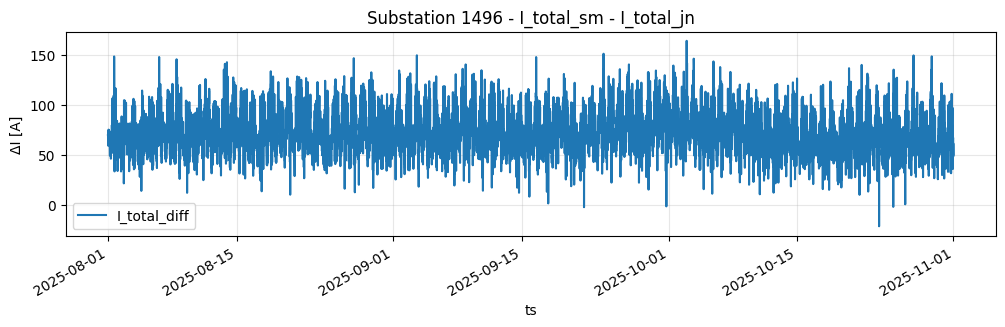

In [47]:
sub = 1496  # change this to whatever you want
trafo = "sp1"
sub_df = (
    df_merged[(df_merged["substation_id"] == sub) & (df_merged["transformer"] == trafo)]
    .set_index("ts")
)


print("Rows for substation", sub, ":", sub_df.shape[0])
sub_df[["I_total_sm", "I_total_jn", "I_total_diff"]].head()

ax = sub_df[["I_total_sm", "I_total_jn"]].plot(
    figsize=(12, 4),
    title=f"Substation {sub} - Total current: smartmeter vs Janitza",
)
ax.set_ylabel("Current [A]")
ax.grid(True, alpha=0.3)
plt.show()

ax2 = sub_df[["I_total_diff"]].plot(
    figsize=(12, 3),
    title=f"Substation {sub} - I_total_sm - I_total_jn",
)
ax2.set_ylabel("ΔI [A]")
ax2.grid(True, alpha=0.3)
plt.show()




Applying CT correction for 1496 sp1...
Correction Factor: 0.5333 (1200A / 2250A)
Rows for substation 1496 : 8830
                     I_total_sm  I_total_jn  I_total_diff
ts                                                       
2025-08-01 00:00:00     431.955  193.385356    238.569644
2025-08-01 00:15:00     430.750  193.141300    237.608700
2025-08-01 00:30:00     424.705  194.996464    229.708536
2025-08-01 00:45:00     428.720  189.521920    239.198080
2025-08-01 01:00:00     421.825  190.443811    231.381189


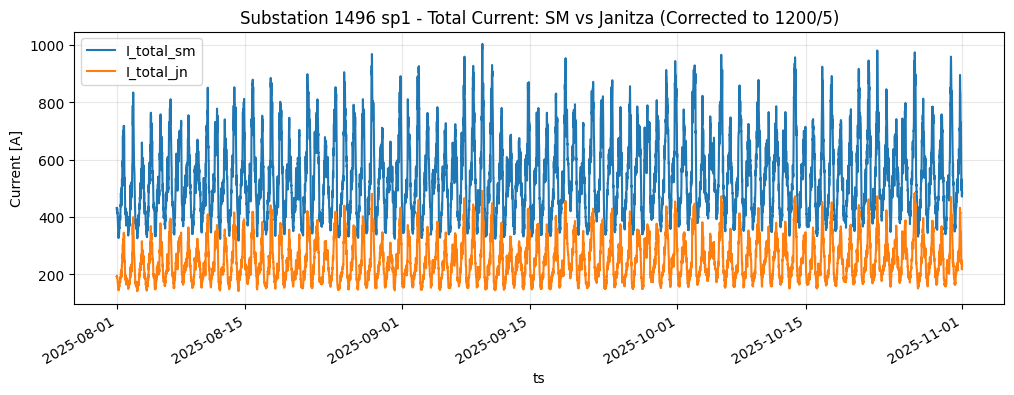

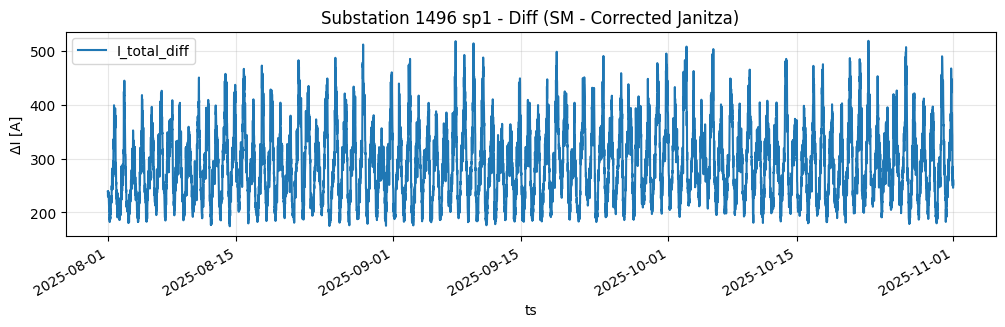

In [48]:
# COMMAND ----------


# 1. Filter the data
sub_df = (
    df_merged[(df_merged["substation_id"] == sub) & (df_merged["transformer"] == trafo)]
    .copy() # Use copy to ensure we don't get SettingWithCopy warnings when modifying
    .set_index("ts")
)

# 2. Apply CT Ratio Correction
# The meter thinks it is 2.25kA (2250A), but it is actually 1200A.
# We must scale the Janitza values DOWN by 1200/2250.
correction_factor = 1200 / 2250 

print(f"Applying CT correction for {sub} {trafo}...")
print(f"Correction Factor: {correction_factor:.4f} (1200A / 2250A)")

# Apply correction to Total and Phase currents
cols_to_fix = ["I_total_jn", "I_a_jn", "I_b_jn", "I_c_jn"]
for col in cols_to_fix:
    if col in sub_df.columns:
        sub_df[col] = sub_df[col] * correction_factor

# 3. Recalculate the difference column based on the NEW Janitza values
sub_df["I_total_diff"] = sub_df["I_total_sm"] - sub_df["I_total_jn"]

# 4. Plotting
print("Rows for substation", sub, ":", sub_df.shape[0])
print(sub_df[["I_total_sm", "I_total_jn", "I_total_diff"]].head())

# Plot 1: Comparison
ax = sub_df[["I_total_sm", "I_total_jn"]].plot(
    figsize=(12, 4),
    title=f"Substation {sub} {trafo} - Total Current: SM vs Janitza (Corrected to 1200/5)",
)
ax.set_ylabel("Current [A]")
ax.grid(True, alpha=0.3)
plt.show()

# Plot 2: Difference
ax2 = sub_df[["I_total_diff"]].plot(
    figsize=(12, 3),
    title=f"Substation {sub} {trafo} - Diff (SM - Corrected Janitza)",
)
ax2.set_ylabel("ΔI [A]")
ax2.grid(True, alpha=0.3)
plt.show()



In [35]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import math

# Try importing statsmodels
try:
    import statsmodels.api as sm
    HAVE_SM = True
except ImportError:
    HAVE_SM = False
    print("⚠️ Statsmodels not found. Fallback to simple quantile ratio.")

def fit_k_no_intercept(df_reg, tau=0.20, min_points=200):

    """
    Fits quantile regression WITHOUT intercept:
      I_total_jn ≈ k0 * I_total_sm_adj
    
    Targeting a low tau (e.g. 0.20) fits the 'lower envelope' of the data,
    ignoring positive biases like NTL or unmetered load.
    """
    rows = []
    # Iterate through every Substation/Transformer group
    for (sid, tr), g in df_reg.groupby(["substation_id", "transformer"]):
        
        # 1. Filters: Enough data?
        if len(g) < min_points:
            continue
            
        # 2. Prepare Vectors
        x = g["I_total_sm_adj"].to_numpy(float)
        y = g["I_total_jn"].to_numpy(float)
        
        # Remove NaNs and zeros/negatives to ensure log-stability if needed
        m = np.isfinite(x) & np.isfinite(y) & (x > 0)
        x = x[m]
        y = y[m]
        
        if len(x) < min_points:
            continue

        # 3. Fit Quantile Regression
        k0 = np.nan
        if HAVE_SM:
            try:
                # QuantReg with no constant column forces intercept to 0
                model = sm.QuantReg(y, x)
                res = model.fit(q=tau, max_iter=2000)
                k0 = float(res.params[0])
            except Exception:
                # Fallback if solver fails
                k0 = float(np.nanquantile(y/x, tau))
        else:
            # Fallback if statsmodels is missing
            k0 = float(np.nanquantile(y/x, tau))

        rows.append({
            "substation_id": sid, 
            "transformer": tr, 
            "tau": tau, 
            "k_hat0": k0, 
            "n_points": len(x)
        })
        
    return pd.DataFrame(rows)

# --- 1. CONFIGURATION ---
min_current = 5.0
min_per_completed = 0.88  # Only trust high coverage bins
min_points = 2000         # Require robust history
target_tau = 0.20         # The quantile to fit (Lower envelope)

# --- 2. DATA PREP ---
df = df_merged.copy()

# Ensure per_completed is a 0.0-1.0 float
df["per_completed"] = pd.to_numeric(df["per_completed"], errors="coerce")
mask_pct = df["per_completed"] > 1.5
df.loc[mask_pct, "per_completed"] = df.loc[mask_pct, "per_completed"] / 100.0
df.loc[(df["per_completed"] <= 0) | (df["per_completed"] > 1.0), "per_completed"] = np.nan

# Calculate Coverage-Adjusted Smart Meter Load
# (If coverage is 90%, we boost SM load by 1/0.9 to estimate full load)
df["I_total_sm_adj"] = df["I_total_sm"] / df["per_completed"]

# Filter Data for Regression (High quality bins only)
df_reg = df[
    (df["I_total_sm"].abs() > min_current) &
    (df["I_total_jn"].abs() > min_current) &
    (df["per_completed"] >= min_per_completed) &
    (df["I_total_sm_adj"] > 0) &
    np.isfinite(df["I_total_sm_adj"]) &
    np.isfinite(df["I_total_jn"])
].copy()

print(f"Regression Dataset: {len(df_reg)} rows across {df_reg.groupby(['substation_id','transformer']).ngroups} groups.")

# --- 3. EXECUTE REGRESSION ---
print(f"Fitting Quantile Regression (tau={target_tau})...")
df_k0 = fit_k_no_intercept(df_reg, tau=target_tau, min_points=min_points)

print(f"Successfully fitted k_hat0 for {len(df_k0)} groups.")
display(df_k0.head())



# Merge the calculated K values back into the main dataset
df_final = df_merged.merge(
    df_k0[["substation_id", "transformer", "k_hat0"]], 
    on=["substation_id", "transformer"], 
    how="left"
)

# Fill missing K with 1.0 (Assume no error if we couldn't fit the model)
df_final["k_hat0"] = df_final["k_hat0"].fillna(1.0)

# Calculate Coverage-Adjusted Smart Meter Load (same as in df)
df_final["I_total_sm_adj"] = df_final["I_total_sm"] / df_final["per_completed"]

# APPLY THE CORRECTION
# Corrected Janitza = Raw Janitza / K
df_final["I_total_jn_corr"] = df_final["I_total_jn"] / df_final["k_hat0"]

# Calculate Residual (Delta)
df_final["Delta"] = df_final["I_total_jn_corr"] - df_final["I_total_sm_adj"]

print("Correction applied. Columns added: 'k_hat0', 'I_total_jn_corr', 'Delta'")
display(df_final[["substation_id", "ts", "I_total_jn", "k_hat0", "I_total_jn_corr", "Delta"]].head())

Regression Dataset: 193082 rows across 22 groups.
Fitting Quantile Regression (tau=0.2)...
Successfully fitted k_hat0 for 22 groups.


,substation_id,transformer,tau,k_hat0,n_points
0,246,sp1,0.2,0.884428,8830
1,411,sp1,0.2,0.935069,8832
2,537,sp1,0.2,0.536463,8832
3,579,sp1,0.2,0.801936,8832
4,670,sp1,0.2,0.887637,8832


Correction applied. Columns added: 'k_hat0', 'I_total_jn_corr', 'Delta'


,substation_id,ts,I_total_jn,k_hat0,I_total_jn_corr,Delta
0,6,2025-08-01 00:00:00,937.155392,1.0,937.155392,-3499.519296
1,6,2025-08-01 00:15:00,905.210505,1.0,905.210505,-3493.688870
2,6,2025-08-01 00:30:00,867.293411,1.0,867.293411,-3524.520964
3,6,2025-08-01 00:45:00,874.602382,1.0,874.602382,-3516.735118
4,6,2025-08-01 01:00:00,839.689068,1.0,839.689068,-3492.618120


Applying CT correction for 1496 sp1 using fitted k_hat0...
Fitted k_hat0: [0.83043371]
Rows for substation 1496 : 8830
                     I_total_sm  I_total_jn_corr  I_total_diff
ts                                                            
2025-08-01 00:00:00     431.955       436.636347     -4.681347
2025-08-01 00:15:00     430.750       436.085305     -5.335305
2025-08-01 00:30:00     424.705       440.273998    -15.568998
2025-08-01 00:45:00     428.720       427.913264      0.806736
2025-08-01 01:00:00     421.825       429.994762     -8.169762


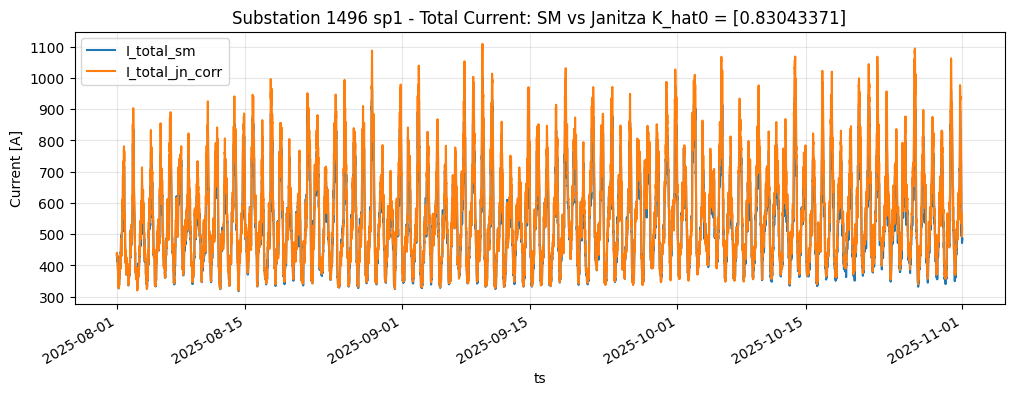

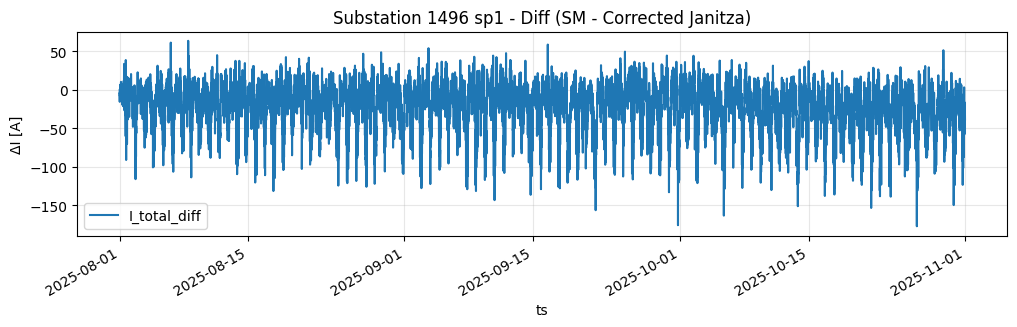

In [51]:
# COMMAND ----------

# 1. Filter the data
sub_df = (
    df_final[(df_final["substation_id"] == sub) & (df_final["transformer"] == trafo)]
    .copy() # Use copy to ensure we don't get SettingWithCopy warnings when modifying
    .set_index("ts")
)
print(f"Applying CT correction for {sub} {trafo} using fitted k_hat0...")
print(f"Fitted k_hat0: {sub_df['k_hat0'].unique()}")

# 3. Recalculate the difference column based on the NEW Janitza values
sub_df["I_total_diff"] = sub_df["I_total_sm"] - sub_df["I_total_jn_corr"]

# 4. Plotting
print("Rows for substation", sub, ":", sub_df.shape[0])
print(sub_df[["I_total_sm", "I_total_jn_corr", "I_total_diff"]].head())

# Plot 1: Comparison
ax = sub_df[["I_total_sm", "I_total_jn_corr"]].plot(
    figsize=(12, 4),
    title=f"Substation {sub} {trafo} - Total Current: SM vs Janitza K_hat0 = {sub_df['k_hat0'].unique()}",
)
ax.set_ylabel("Current [A]")
ax.grid(True, alpha=0.3)
plt.show()

# Plot 2: Difference
ax2 = sub_df[["I_total_diff"]].plot(
    figsize=(12, 3),
    title=f"Substation {sub} {trafo} - Diff (SM - Corrected Janitza)",
)
ax2.set_ylabel("ΔI [A]")
ax2.grid(True, alpha=0.3)
plt.show()


plt.show()

count    8832.000000
mean        1.651385
std         0.055853
min         1.404349
25%         1.612594
50%         1.648757
75%         1.688232
max         2.026835
Name: ratio, dtype: float64
Scale factor k = 1.6632393795880573
R^2 = 0.9857957302850354


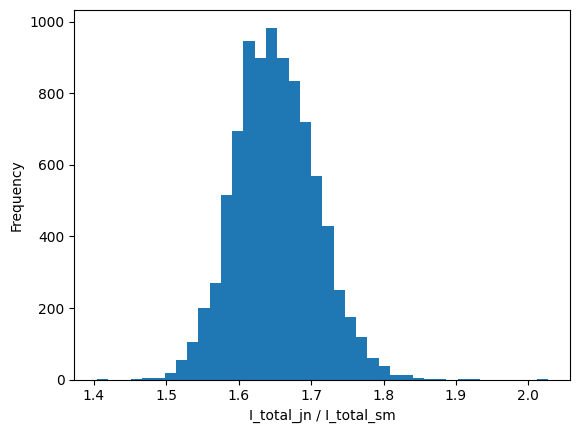

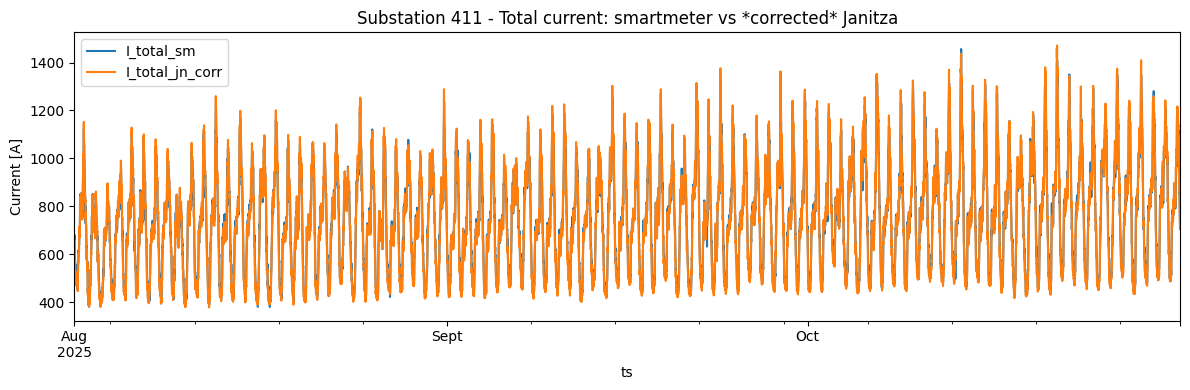

In [27]:
aligned = sub_df[["I_total_sm", "I_total_jn"]].dropna()

# avoid division by tiny numbers – only look when load is “significant”
min_current = 50  # A, tune this
mask = aligned["I_total_sm"] > min_current
subset = aligned[mask].copy()

subset["ratio"] = subset["I_total_jn"] / subset["I_total_sm"]
print(subset["ratio"].describe())

subset["ratio"].plot(kind="hist", bins=40)
plt.xlabel("I_total_jn / I_total_sm")


from sklearn.linear_model import LinearRegression
import numpy as np

X = subset[["I_total_sm"]].values
y = subset["I_total_jn"].values

reg = LinearRegression(fit_intercept=False).fit(X, y)
k = reg.coef_[0]
r2 = reg.score(X, y)

print("Scale factor k =", k)
print("R^2 =", r2)

# --- 1) use your fitted scale factor (through-origin regression) ---
k = reg.coef_[0] #*0.94  # from your output

aligned = aligned.copy()
aligned["I_total_jn_corr"] = aligned["I_total_jn"] / k

# --- 2) plot smartmeter vs *corrected* Janitza ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))

aligned[["I_total_sm", "I_total_jn_corr"]].plot(ax=ax)

ax.set_title("Substation 411 - Total current: smartmeter vs *corrected* Janitza")
ax.set_ylabel("Current [A]")
ax.set_xlabel("ts")
ax.legend(["I_total_sm", "I_total_jn_corr"])

plt.tight_layout()
plt.show()




In [29]:

sub_stats = (
    merged
    .groupby("substation_id")
    .agg(
        mean_I_total_sm = ("I_total_sm", "mean"),
        mean_I_total_jn = ("I_total_jn", "mean"),
        mean_diff       = ("I_total_diff", "mean"),      # same as above two minus each other
    )
)

# (Optional) sort by difference so the bar chart is easier to read
sub_stats = sub_stats.sort_values("mean_diff")

# 2) Prepare data for plotting
x = np.arange(len(sub_stats))
y = sub_stats["mean_diff"].values
subs = sub_stats.index.astype(int)

# Color: blue if smartmeter > Janitza, orange otherwise
colors = ["tab:blue" if val > 0 else "tab:orange" for val in y]

# 3) Plot
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(x, y, color=colors)

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean I_total_sm - I_total_jn [A]")
ax.set_title("Per-substation difference in mean total current\n"
             "(blue: smartmeter higher, orange: Janitza higher)")

plt.tight_layout()
plt.show()


NameError: name 'merged' is not defined

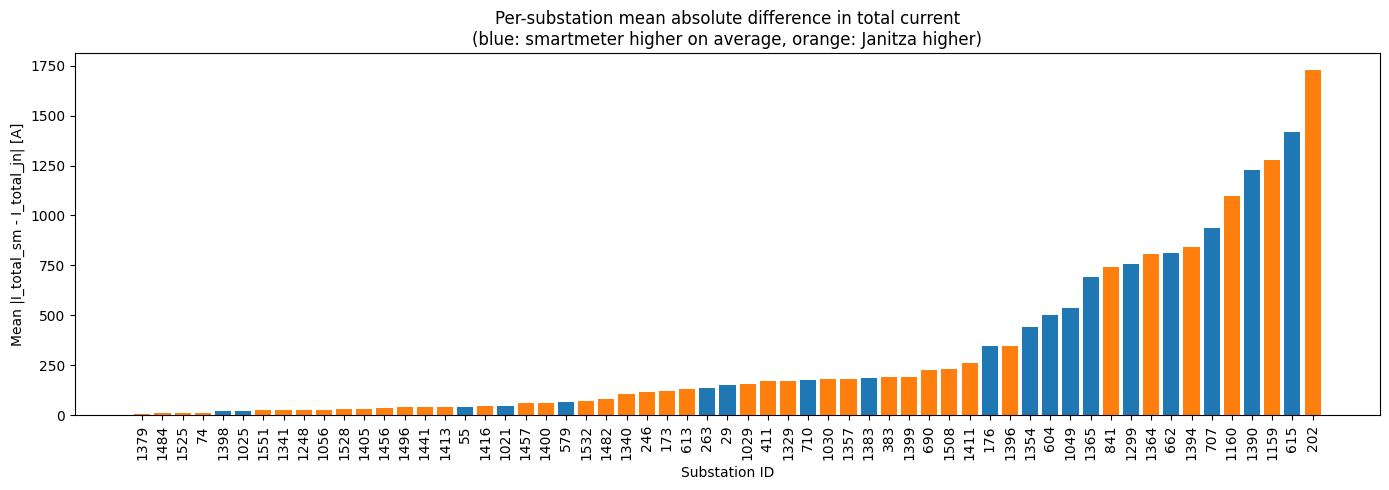

In [8]:
sub_stats["mean_abs_diff"] = (
    merged
    .groupby("substation_id")["I_total_diff"]
    .apply(lambda s: s.abs().mean())
)

sub_stats = sub_stats.sort_values("mean_abs_diff")

x = np.arange(len(sub_stats))
height = sub_stats["mean_abs_diff"].values
sign   = sub_stats["mean_diff"].values  # from previous aggregation
colors = ["tab:blue" if val > 0 else "tab:orange" for val in sign]
subs   = sub_stats.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, height, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean |I_total_sm - I_total_jn| [A]")
ax.set_title("Per-substation mean absolute difference in total current\n"
             "(blue: smartmeter higher on average, orange: Janitza higher)")
plt.tight_layout()
plt.show()


Number of substations with n_mps >= 1: 59
Number of substations with per_completed >= 1: 9


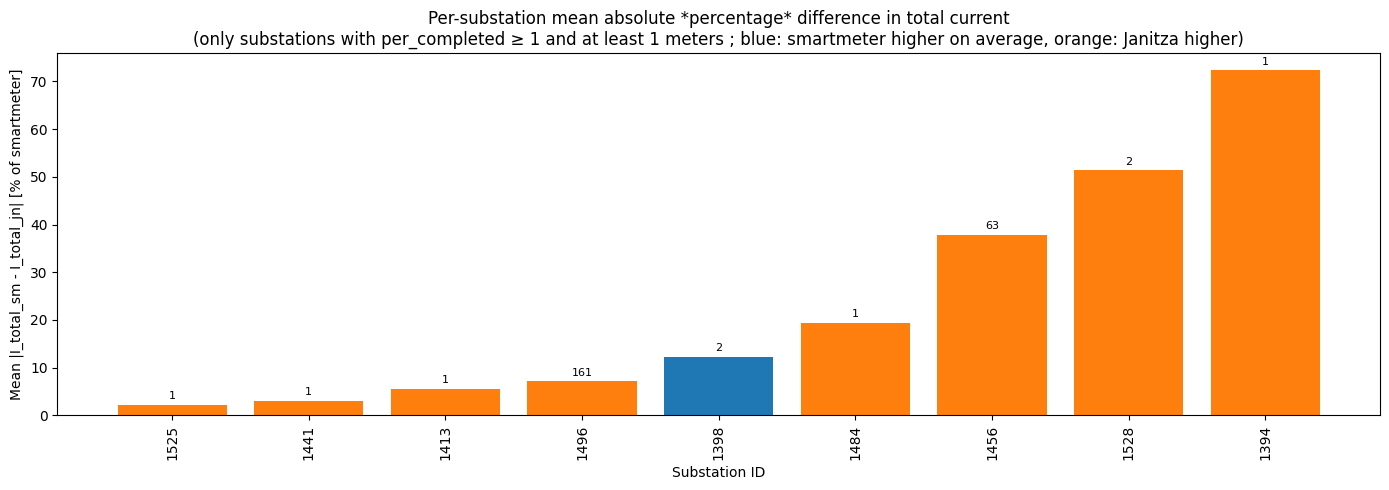

In [9]:


# Per-sample absolute percentage diff (NaN if smartmeter current is 0)
merged["I_total_abs_pct_diff"] = (
    100 * merged["I_total_diff"].abs() / merged["I_total_sm"].replace(0, np.nan)
)

sub_stats["mean_abs_pct_diff"] = (
    merged
    .groupby("substation_id")["I_total_abs_pct_diff"]
    .mean()
)


# Append per_completed (already in merged) aggregated per substation
sub_stats["per_completed"] = (
    merged
    .groupby("substation_id")["per_completed"]
    .max()
)
# Append n_mps (number of smartmeters) aggregated per substation
sub_stats["n_mps"] = (
    merged
    .groupby("substation_id")["n_mps"]
    .max()
)
# --- cutoff on per_completed ---
cutoff = 1#0.9  # change this threshold as you like
min_num = 1  # minimum number of smartmeters

sub_stats_num = sub_stats[sub_stats["n_mps"] >= min_num].copy()
print(f"Number of substations with n_mps >= {min_num}: {len(sub_stats_num)}")

sub_stats_pct = (
    sub_stats_num[sub_stats_num["per_completed"] >= cutoff]
    .sort_values("mean_abs_pct_diff")
)

print(f"Number of substations with per_completed >= {cutoff}: {len(sub_stats_pct)}")

# Plot
x      = np.arange(len(sub_stats_pct))
height = sub_stats_pct["mean_abs_pct_diff"].to_numpy(dtype=float)
sign   = sub_stats_pct["mean_diff"].to_numpy(dtype=float)
n_mps_vals = sub_stats_pct["n_mps"].to_numpy(dtype=int)
colors  = ["tab:blue" if val > 0 else "tab:orange" for val in sign]
subs    = sub_stats_pct.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, height, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean |I_total_sm - I_total_jn| [% of smartmeter]")
ax.set_title(
    f"Per-substation mean absolute *percentage* difference in total current\n"
    f"(only substations with per_completed ≥ {cutoff} and at least {min_num} meters ; "
    f"blue: smartmeter higher on average, orange: Janitza higher)"
)

# --- add n_mps labels above each bar ---  # NEW
offset = 0.01 * (height.max() if len(height) else 1.0)
for xi, hi, n in zip(x, height, n_mps_vals):
    ax.text(
        xi,
        hi + offset,
        str(n),
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=0,
    )

plt.tight_layout()
plt.show()


Here we look at power

In [10]:
# Paths assuming notebook is in src/phasebalance
sm_path_power = "../data/smartmeter_15min_all_from_devices_20251101_20251103_power.parquet"
jn_path_power = "../data/janitza_3phase_P_all_20251101_1200_20251103_1200.parquet"

df_sm_power = pd.read_parquet(sm_path_power)
df_jn_power = pd.read_parquet(jn_path_power)


print("Smartmeter shape:", df_sm_power.shape)
print("Janitza shape   :", df_jn_power.shape)
print("Smartmeter cols:", df_sm_power.columns.tolist())
print("Janitza cols   :", df_jn_power.columns.tolist())

# 1) Parse dnr_str -> substation_id on the Janitza side
df_jn_power["substation_id"] = df_jn_power["dnr_str"].map(parse_dnr)

# 2) Ensure timestamps are datetime
df_sm_power["ts"] = pd.to_datetime(df_sm_power["ts"])
df_jn_power["ts"] = pd.to_datetime(df_jn_power["ts"])

# 3) Sort for sanity
df_sm_power = df_sm_power.sort_values(["substation_id", "ts"])
df_jn_power = df_jn_power.sort_values(["substation_id", "ts"])

#Change df_sm_power column names to match df_janitza_power columns. From "['substation_id', 'ts', 'I_a', 'I_b', 'I_c', 'I_total', 'n_mps', 'per_completed']" to "['substation_id', 'ts', 'P_a', 'P_b', 'P_c', 'P_total', 'n_mps', 'per_completed']"
df_sm_power = df_sm_power.rename(columns={"I_a" : "P_a", "I_b": "P_b", "I_c": "P_c", "I_total": "P_total"})

Smartmeter shape: (24565, 8)
Janitza shape   : (19299, 6)
Smartmeter cols: ['substation_id', 'ts', 'I_a', 'I_b', 'I_c', 'I_total', 'n_mps', 'per_completed']
Janitza cols   : ['ts', 'P_a', 'P_b', 'P_c', 'P_total', 'dnr_str']


In [11]:
# Force both ts columns to be UTC -> then drop timezone (naive but aligned)
df_sm_power["ts"] = pd.to_datetime(df_sm_power["ts"], utc=True).dt.tz_localize(None)
df_jn_power["ts"] = pd.to_datetime(df_jn_power["ts"], utc=True).dt.tz_localize(None)

print("df_sm ts dtype:", df_sm_power["ts"].dtype)
print("df_jn ts dtype:", df_jn_power["ts"].dtype)



# Merge on substation_id + ts (inner join = only overlapping timestamps)
merged = df_sm_power.merge(
    df_jn_power,
    on=["substation_id", "ts"],
    how="inner",
    suffixes=("_sm", "_jn"),
)

print("Merged shape:", merged.shape)
merged[["substation_id", "ts"]].head()

for col in ["P_a", "P_b", "P_c", "P_total"]:
    merged[f"{col}_diff"] = merged[f"{col}_sm"] - merged[f"{col}_jn"]

merged[["P_a_diff", "P_b_diff", "P_c_diff", "P_total_diff"]].describe()


df_sm ts dtype: datetime64[ns]
df_jn ts dtype: datetime64[ns]
Merged shape: (16210, 13)


,P_a_diff,P_b_diff,P_c_diff,P_total_diff
count,1.621000e+04,1.621000e+04,1.621000e+04,1.621000e+04
mean,1.657421e+04,-1.084288e+04,-1.244969e+04,-6.718363e+03
std,9.369295e+04,9.102135e+04,9.163814e+04,2.674595e+05
min,-1.209970e+06,-1.350138e+06,-1.198249e+06,-3.758357e+06
25%,-4.751091e+02,-1.697638e+04,-1.658948e+04,-1.577822e+04
50%,1.667088e+04,-2.474613e+03,-2.836391e+03,4.617927e+03
75%,4.907527e+04,3.957319e+03,4.308333e+03,4.387814e+04
max,2.889146e+05,2.881540e+05,2.892423e+05,8.663109e+05


Rows for substation 1400 : 288


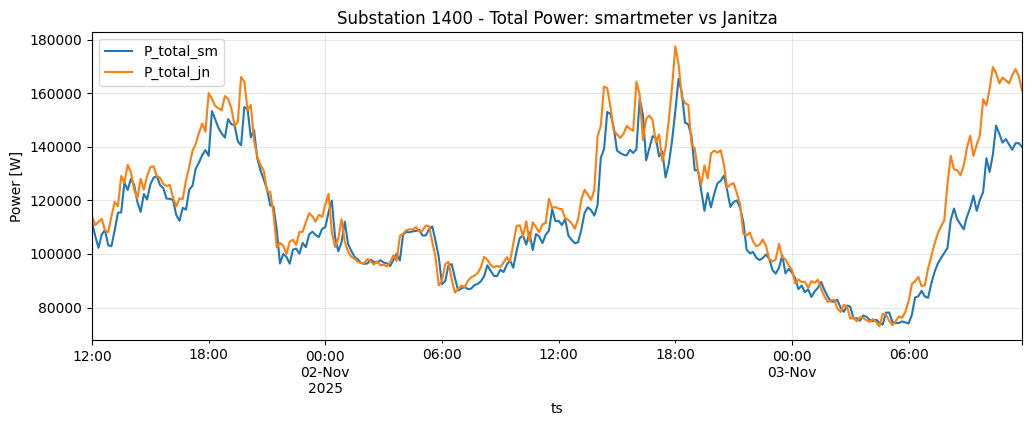

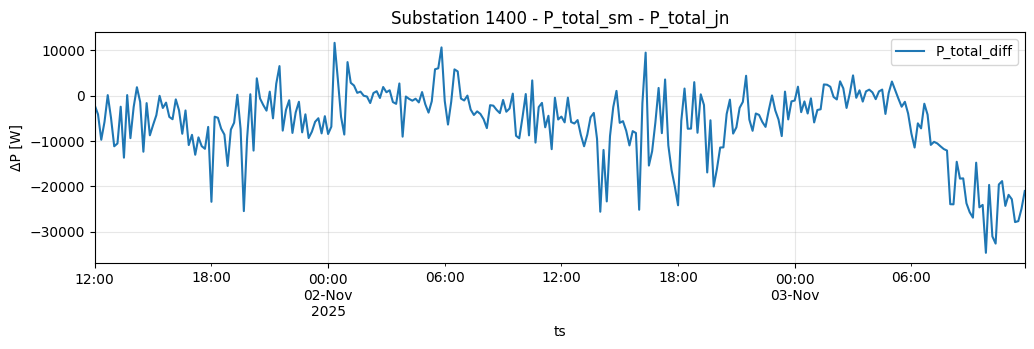

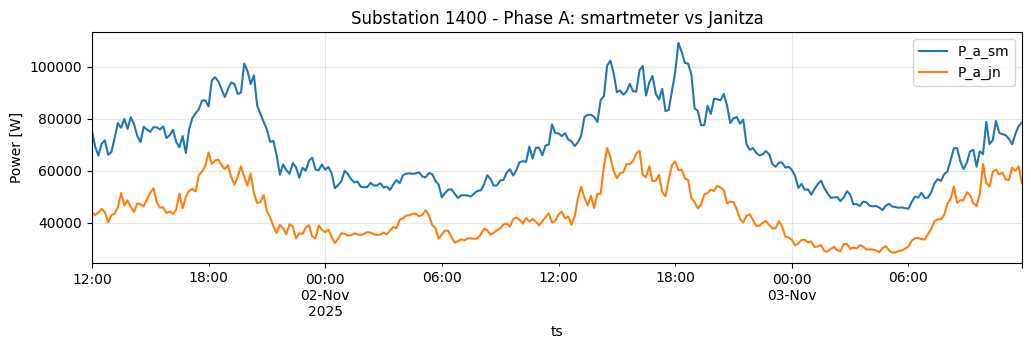

In [12]:
sub = 1400  # change this to whatever you want

sub_df = (
    merged[merged["substation_id"] == sub]
    .set_index("ts")
    .sort_index()
)

print("Rows for substation", sub, ":", sub_df.shape[0])
sub_df[["P_total_sm", "P_total_jn", "P_total_diff"]].head()

ax = sub_df[["P_total_sm", "P_total_jn"]].plot(
    figsize=(12, 4),
    title=f"Substation {sub} - Total Power: smartmeter vs Janitza",
)
ax.set_ylabel("Power [W]")
ax.grid(True, alpha=0.3)
plt.show()

ax2 = sub_df[["P_total_diff"]].plot(
    figsize=(12, 3),
    title=f"Substation {sub} - P_total_sm - P_total_jn",
)
ax2.set_ylabel("ΔP [W]")
ax2.grid(True, alpha=0.3)
plt.show()

ax3 = sub_df[["P_a_sm", "P_a_jn"]].plot(
    figsize=(12, 3),
    title=f"Substation {sub} - Phase A: smartmeter vs Janitza",
)
ax3.set_ylabel("Power [W]")
ax3.grid(True, alpha=0.3)
plt.show()


Number of substations with n_mps >= 1: 53
Number of substations with per_completed >= 0.9: 21


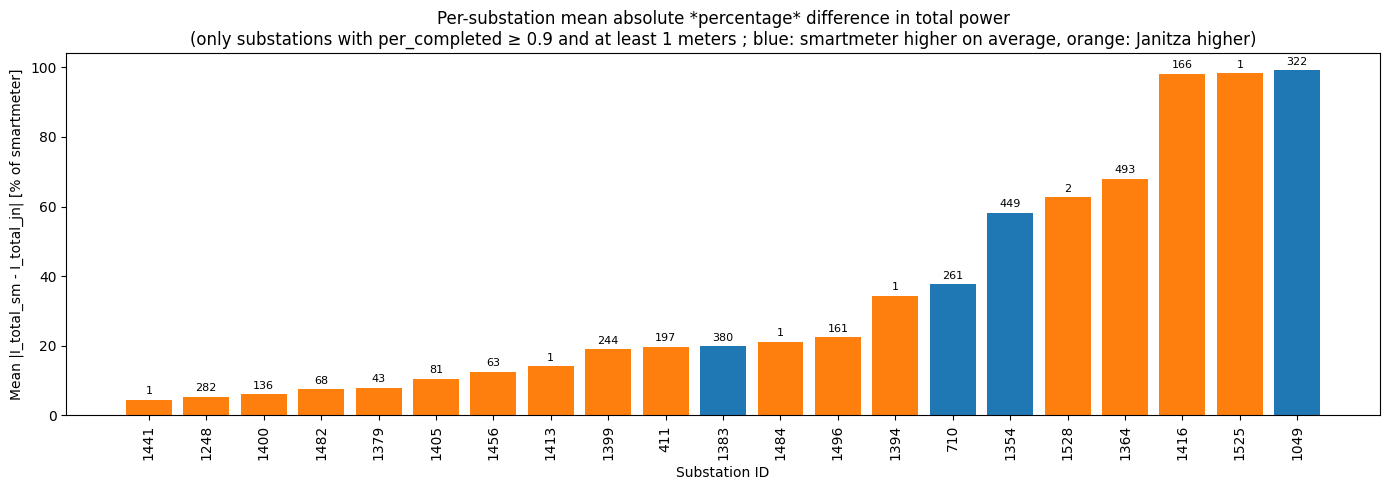

In [13]:
# Mean absolute *percentage* difference per substation (relative to smartmeter)

# Per-sample absolute percentage diff (NaN if smartmeter current is 0)
merged["P_total_abs_pct_diff"] = (
    100 * merged["P_total_diff"].abs() / merged["P_total_sm"].replace(0, np.nan)
)

# Aggregate per substation
sub_stats["mean_abs_pct_diff"] = (
    merged
    .groupby("substation_id")["P_total_abs_pct_diff"]
    .mean()
)

# Append per_completed (already in merged) aggregated per substation
sub_stats["per_completed"] = (
    merged
    .groupby("substation_id")["per_completed"]
    .max()
)
# Append n_mps (number of smartmeters) aggregated per substation
sub_stats["n_mps"] = (
    merged
    .groupby("substation_id")["n_mps"]
    .max()
)
# --- cutoff on per_completed ---
cutoff = 0.9  # change this threshold as you like
min_num = 1  # minimum number of smartmeters

sub_stats_num = sub_stats[sub_stats["n_mps"] >= min_num].copy()
print(f"Number of substations with n_mps >= {min_num}: {len(sub_stats_num)}")

sub_stats_pct = (
    sub_stats_num[sub_stats_num["per_completed"] >= cutoff]
    .sort_values("mean_abs_pct_diff")
)

print(f"Number of substations with per_completed >= {cutoff}: {len(sub_stats_pct)}")

# Plot
x      = np.arange(len(sub_stats_pct))
height = sub_stats_pct["mean_abs_pct_diff"].to_numpy(dtype=float)
sign   = sub_stats_pct["mean_diff"].to_numpy(dtype=float)
n_mps_vals = sub_stats_pct["n_mps"].to_numpy(dtype=int)
colors  = ["tab:blue" if val > 0 else "tab:orange" for val in sign]
subs    = sub_stats_pct.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, height, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean |I_total_sm - I_total_jn| [% of smartmeter]")
ax.set_title(
    f"Per-substation mean absolute *percentage* difference in total power\n"
    f"(only substations with per_completed ≥ {cutoff} and at least {min_num} meters ; "
    f"blue: smartmeter higher on average, orange: Janitza higher)"
)

# --- add n_mps labels above each bar ---  # NEW
offset = 0.01 * (height.max() if len(height) else 1.0)
for xi, hi, n in zip(x, height, n_mps_vals):
    ax.text(
        xi,
        hi + offset,
        str(n),
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=0,
    )

plt.tight_layout()
plt.show()


This is the voltage


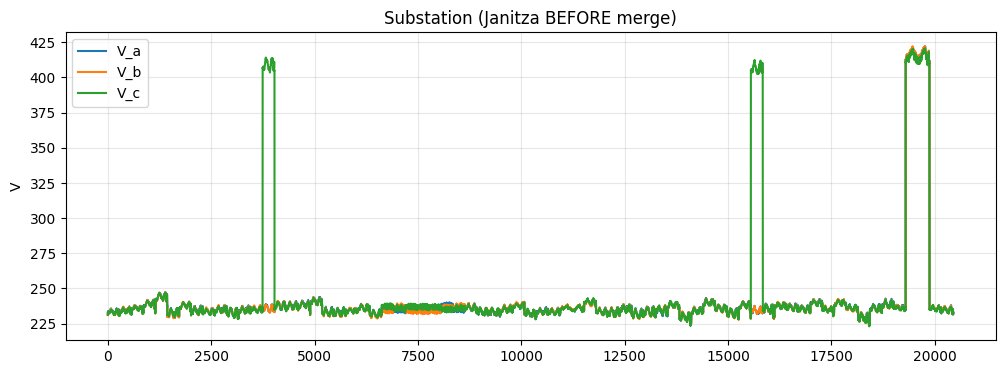

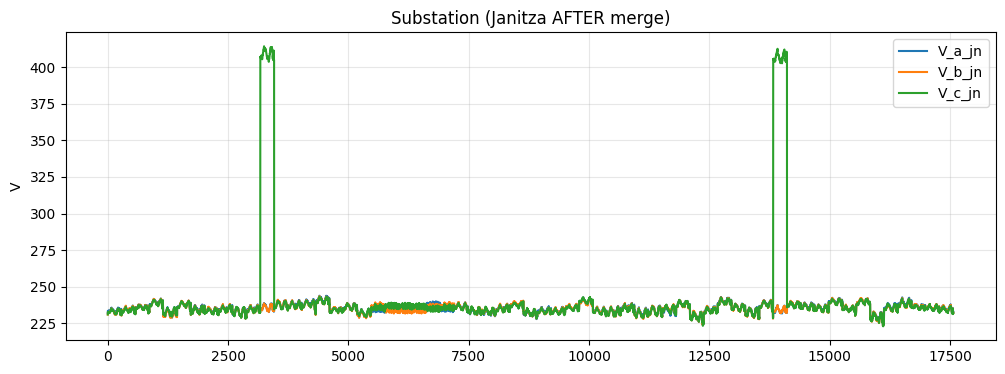

In [14]:
SM_voltage = "../data/smartmeter_15min_all_from_devices_20251101_20251103_voltage.parquet"  # smartmeter voltage
df_sm_voltage = pd.read_parquet(SM_voltage)

J_voltage = "../data/janitza_3phase_V_all_20251101_1200_20251103_1200.parquet"  # Janitza voltage
df_J_voltage = pd.read_parquet(J_voltage)

# Map Janitza dnr_str → substation_id
df_J_voltage["substation_id"] = df_J_voltage["dnr_str"].map(parse_dnr)

# Ensure timestamps are aligned
df_sm_voltage["ts"] = pd.to_datetime(df_sm_voltage["ts"], utc=True).dt.tz_localize(None)
df_J_voltage["ts"] = pd.to_datetime(df_J_voltage["ts"], utc=True).dt.tz_localize(None)

# IMPORTANT: use JANITZA as the LEFT side of the merge
# so its row order and voltages are preserved.
df = df_J_voltage.merge(
    df_sm_voltage,
    on=["ts", "substation_id"],
    how="inner",              # or "left" if you want to keep all Janitza rows
    suffixes=("_jn", "_sm"),  # Janitza columns get _jn
)

# ---- Plot Janitza BEFORE merge (all substations, raw order, index = 0..N-1) ----
ax = df_J_voltage[["V_a", "V_b", "V_c"]].plot(
    figsize=(12, 4),
    title="Substation (Janitza BEFORE merge)",
)
ax.set_ylabel("V")
ax.grid(True, alpha=0.3)
plt.show()

# ---- Plot Janitza AFTER merge (same ordering, same index) ----
ax = df[["V_a_jn", "V_b_jn", "V_c_jn"]].plot(
    figsize=(12, 4),
    title="Substation (Janitza AFTER merge)",
)
ax.set_ylabel("V")
ax.grid(True, alpha=0.3)
plt.show()


Max rows per (substation_id, ts) in Janitza: 1
Max rows per (substation_id, ts) in SM voltage: 1
Merged voltage shape: (17567, 10)
    substation_id    V_corr  n_points
47           1413  0.981005       288
57           1528  0.980363       288
39           1383  0.979006       288
54           1496  0.978100       288
42           1396  0.977857       288
..            ...       ...       ...
52           1482  0.724479       287
22           1030  0.640324       288
23           1049  0.634069       288
24           1056  0.566318       288
21           1029  0.394570       288

[61 rows x 3 columns]


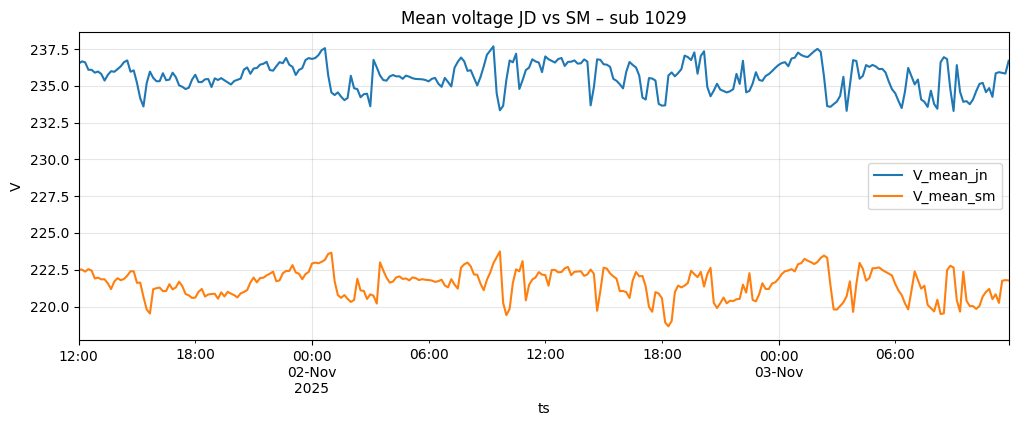

In [15]:
# Janitza uniqueness
jn_dup = (
    df_J_voltage.groupby(["substation_id", "ts"])
    .size()
    .reset_index(name="count")
)
print("Max rows per (substation_id, ts) in Janitza:", jn_dup["count"].max())

# Smartmeter voltage uniqueness
sm_dup = (
    df_sm_voltage.groupby(["substation_id", "ts"])
    .size()
    .reset_index(name="count")
)
print("Max rows per (substation_id, ts) in SM voltage:", sm_dup["count"].max())

sm_agg = (
    df_sm_voltage
    .groupby(["substation_id", "ts"])[["V_a", "V_b", "V_c"]]
    .mean()
    .reset_index()
)

# Make sure timestamps are aligned & tz-naive (you already do this)
df_J_voltage["ts"] = pd.to_datetime(df_J_voltage["ts"], utc=True).dt.tz_localize(None)
df_sm_voltage["ts"] = pd.to_datetime(df_sm_voltage["ts"], utc=True).dt.tz_localize(None)

# If you needed aggregation, use sm_agg. Otherwise:
sm_agg = df_sm_voltage  # if one row per (sub, ts) already

df_v = df_J_voltage.merge(
    sm_agg,
    on=["substation_id", "ts"],
    how="inner",
    suffixes=("_jn", "_sm"),
)

print("Merged voltage shape:", df_v.shape)

df_v["V_mean_jn"] = df_v[["V_a_jn", "V_b_jn", "V_c_jn"]].mean(axis=1)
df_v["V_mean_sm"] = df_v[["V_a_sm", "V_b_sm", "V_c_sm"]].mean(axis=1)


def compute_voltage_corr(df_v, min_points: int = 20) -> pd.DataFrame:
    rows = []
    for sid, g in df_v.groupby("substation_id"):
        g = g.dropna(subset=["V_mean_jn", "V_mean_sm"])
        if len(g) < min_points:
            continue
        corr = g["V_mean_jn"].corr(g["V_mean_sm"])
        rows.append({
            "substation_id": sid,
            "V_corr": corr,
            "n_points": len(g),
        })
    return pd.DataFrame(rows)

voltage_corr_summary = compute_voltage_corr(df_v)
print(voltage_corr_summary.sort_values("V_corr", ascending=False).head(90))

sub = 1029  # pick a substation to inspect
g = df_v[df_v["substation_id"] == sub].sort_values("ts")

ax = g.set_index("ts")[["V_mean_jn", "V_mean_sm"]].plot(
    figsize=(12, 4),
    title=f"Mean voltage JD vs SM – sub {sub}",
)
ax.set_ylabel("V")
ax.grid(True, alpha=0.3)
plt.show()
